# Random Forest Regressor — Predicción de Estrés


El objetivo es predecir el nivel de **estrés futuro** en una zona geográfica, agregado por hora y día. Se definen **tres targets** distintos que representan el estrés en diferentes horizontes temporales:
 
| Target | Horizonte |
|---|---|
| `target_stress_t1` | +1 hora |
| `target_stress_t3` | +3 horas |
| `target_stress_t24` | +24 horas |
 
Se entrena **un modelo independiente por target**, todos con la misma arquitectura: **RandomForestRegressor sobre Spark ML**.


Los datos provienen de un dataset de parquets particionados en `data/aggregated/ex_stress/df_stress_zone_hour_day`. Se filtran filas donde el target o el timestamp sean nulos.
 
La partición es **temporal estricta** (no aleatoria), lo cual es crítico para evitar data leakage en series temporales:
 
```
Train: 70%  →  Val: 15%  →  Test: 15%
```
 
El split se hace por `timestamp_hour`, preservando el orden cronológico. Los bounds (fechas de corte) se guardan en el report JSON.


## Preprocesamiento y pipeline
 
El pipeline de Spark ML tiene las siguientes etapas en orden:
 
### a) Encoding de categóricas
- `StringIndexer` convierte cada columna string a índice numérico (`col__idx`)
- Por defecto **no se aplica OneHotEncoder** (mejor para árboles: evita explosión de memoria y dimensionalidad)
- Si se activa `--one-hot-cats`, se añade un `OneHotEncoder` tras el indexer
### b) Ensamblado de features
- `VectorAssembler` une todas las columnas numéricas + las categóricas codificadas en un único vector `features`
- `handleInvalid="keep"` en todas las etapas → los nulos se gestionan sin romper el pipeline
### c) Modelo
- `RandomForestRegressor` con `labelCol="label"` y `featuresCol="features"`


## Hiperparámetros
 
**Defaults conservadores** (orientados a entornos con recursos limitados):
 
| Parámetro | Default | Descripción |
|---|---|---|
| `numTrees` | 100 | Nº de árboles del bosque |
| `maxDepth` | 8 | Profundidad máxima por árbol |
| `subsamplingRate` | 0.6 | Fracción de datos por árbol |
| `maxBins` | 16 | Bins para discretizar features continuas |
| `maxMemoryInMB` | 32 | Memoria por nodo/partición para el algoritmo |
| `minInstancesPerNode` | 2 | Mínimo de muestras por hoja |
| `featureSubsetStrategy` | `sqrt` | Nº de features candidatas por split |


## Búsqueda de hiperparámetros (tuning)
 
Cuando se activa `--tune`, se realiza un **grid search manual sobre validación temporal**:
 
- Grid por defecto: `numTrees ∈ {80,100,120}`, `maxDepth ∈ {7,8}`, `subsamplingRate ∈ {0.5,0.6}`, `maxBins ∈ {16}`, `maxMemoryInMB ∈ {32}`
- Se muestrea una fracción de train/val para acelerar (`tune_train_sample_frac`, `tune_val_sample_frac`)
- Métrica de selección configurable: `rmse` (default), `mae`, o `r2`
- El mejor trial se guarda en `random_forest_stress_spark_tuning_report.json` y todos los trials en `random_forest_stress_spark_tuning_trials.csv`


## Protocolo de entrenamiento y evaluación
 
```
[Train] → fit pipeline → predice en Train, Val, Test  (detectar overfitting)
           ↓
[Train + Val] → refit con mejores hiperparámetros → predice en Test  (modelo final)
```
 
- El **modelo base** (solo train) sirve para medir overfitting mirando los gaps entre splits.
- El **refit train+val** es el modelo final que se guarda y se usa para evaluar en test.
- Opcionalmente, `--fit-all-data` entrena un tercer modelo sobre train+val+test para despliegue (sus métricas son in-sample y no válidas para medir generalización).

**Métricas calculadas:** `MAE`, `RMSE`, `R²`
 
**Overfit gaps calculados automáticamente:**
- `val_rmse - train_rmse`
- `test_rmse - train_rmse`
- `train_r2 - val_r2`
- `train_r2 - test_r2`


## A) Análisis numérico


**1. Desempeño y Generalización**

A partir de las métricas obtenidas para los tres horizontes temporales (+1h, +3h y +24h), observamos un comportamiento sólido del modelo Random Forest:

- **Buena generalización en los tres targets:** el modelo mantiene brechas moderadas entre train, validation y test final, sin señales de sobreajuste severo.
- **Capacidad predictiva alta y estable:** en test final, el $R^2$ se mantiene en torno a **0.75 - 0.79** (`+1h: 0.7863`, `+3h: 0.7474`, `+24h: 0.7744`), con errores MAE entre `0.499` y `0.557`.
- **Patrón temporal coherente:** el horizonte `+3h` resulta el más exigente (mayor RMSE), mientras que `+1h` y `+24h` muestran mejor ajuste, consistente con continuidad de corto plazo y estacionalidad diaria.


In [1]:
import json
import os
import pandas as pd

base_path = "../outputs/ejercicio2/random_forest/"
targets = ["t1", "t3", "t24"]

results = []

for target in targets:
    report_path = os.path.join(base_path, target, "random_forest_stress_spark_report.json")

    with open(report_path, "r") as f:
        data = json.load(f)

        metrics = data.get("metrics", {})
        train_fit = metrics.get("train_fit", {})
        refit = metrics.get("train_val_refit", {})

        # Extraemos Train y Val del primer fit (para evaluar overfit base)
        train_metrics = train_fit.get("train_seen", {})
        val_metrics = train_fit.get("val_unseen", {})

        # Extraemos Test del modelo final reentrenado (Train + Val)
        test_metrics = refit.get("test_unseen", {})

        row = {
            "Target": f"+{target.replace('t', '')}h",
            "Train R²": round(train_metrics.get("r2", 0), 4),
            "Val R²": round(val_metrics.get("r2", 0), 4),
            "Test Final R²": round(test_metrics.get("r2", 0), 4),
            "Train RMSE": round(train_metrics.get("rmse", 0), 4),
            "Val RMSE": round(val_metrics.get("rmse", 0), 4),
            "Test Final RMSE": round(test_metrics.get("rmse", 0), 4),
            "Train MAE": round(train_metrics.get("mae", 0), 4),
            "Val MAE": round(val_metrics.get("mae", 0), 4),
            "Test Final MAE": round(test_metrics.get("mae", 0), 4),
        }
        results.append(row)


df_metrics = pd.DataFrame(results)
display(df_metrics)


,Target,Train R²,Val R²,Test Final R²,Train RMSE,Val RMSE,Test Final RMSE,Train MAE,Val MAE,Test Final MAE
0,+1h,0.7983,0.7861,0.7863,0.7343,0.7705,0.7935,0.4676,0.4842,0.4990
1,+3h,0.7639,0.7530,0.7474,0.7946,0.8277,0.8629,0.5219,0.5353,0.5566
2,+24h,0.7872,0.7771,0.7744,0.7543,0.7865,0.8154,0.4887,0.5031,0.5221


**2. Overfit gaps**

Los gaps entre entrenamiento y evaluación futura son contenidos y bastante homogéneos:

- En el modelo final (`train+val -> test`), el incremento de RMSE está alrededor de **0.053 - 0.063** según el target.
- La caída de $R^2$ frente a `train_val` es pequeña, en torno a **0.010 - 0.015**.
- Esto confirma que el pipeline temporal y la regularización implícita del bosque (`maxDepth`, `subsamplingRate`) están controlando bien el riesgo de sobreajuste.


In [2]:
results_gaps = []

for target in targets:
    report_path = os.path.join(base_path, target, "random_forest_stress_spark_report.json")

    with open(report_path, "r") as f:
        data = json.load(f)

        metrics = data.get("metrics", {})

        # Gaps del primer entrenamiento (Train -> Val)
        train_fit_gaps = metrics.get("train_fit", {}).get("overfit_gaps", {})

        # Gaps del modelo final reentrenado (Train+Val -> Test)
        refit_gaps = metrics.get("train_val_refit", {}).get("overfit_gaps", {})

        row = {
            "Target": f"+{target.replace('t', '')}h",
            "Val - Train RMSE (Base)": round(train_fit_gaps.get("val_minus_train_rmse", 0), 4),
            "Train - Val R² (Base)": round(train_fit_gaps.get("train_minus_val_r2", 0), 4),
            "Test - TrainVal RMSE (Final)": round(refit_gaps.get("test_minus_train_val_rmse", 0), 4),
            "TrainVal - Test R² (Final)": round(refit_gaps.get("train_val_minus_test_r2", 0), 4),
        }
        results_gaps.append(row)


df_gaps = pd.DataFrame(results_gaps)
display(df_gaps)


,Target,Val - Train RMSE (Base),Train - Val R² (Base),Test - TrainVal RMSE (Final),TrainVal - Test R² (Final)
0,+1h,0.0362,0.0123,0.0532,0.0102
1,+3h,0.0332,0.0109,0.0632,0.0151
2,+24h,0.0322,0.0101,0.0558,0.0114


**3. Análisis del tuning**

Revisando los Top 3 trials por horizonte temporal se observan patrones claros:

- **Zona óptima estable:** las mejores combinaciones convergen en `maxDepth=8`, con `numTrees` entre `80` y `100` y `subsamplingRate` entre `0.5` y `0.6`.
- **Diferencias pequeñas entre trials top:** la separación en `val_rmse` entre el mejor y el tercer trial es reducida en cada target, señal de robustez del modelo.
- **Sin dependencia de un único trial “mágico”:** el rendimiento se mantiene competitivo en varias configuraciones cercanas, lo que da confianza para reproducibilidad operativa.


In [3]:
dfs = []

for target in targets:
    csv_path = os.path.join(base_path, target, "random_forest_stress_spark_tuning_trials.csv")

    df = pd.read_csv(csv_path)

    # Filtrar exitosos y ordenar por val_rmse de mejor a peor
    df_ok = df[df["status"] == "ok"].copy()
    df_top = df_ok.sort_values(by="val_rmse", ascending=True).head(3).copy()

    # Seleccionar columnas clave para análisis
    df_top = df_top[["trial", "rf_num_trees", "rf_max_depth", "rf_subsampling_rate", "val_rmse"]]

    # Añadir columna de target
    df_top.insert(0, "Target", f"+{target.replace('t', '')}h")

    dfs.append(df_top)

# Juntar y renombrar para presentación
df_tuning = pd.concat(dfs, ignore_index=True)
df_tuning.columns = ["Target", "Trial", "Num Trees", "Max Depth", "Subsampling", "Val RMSE"]
display(df_tuning)


,Target,Trial,Num Trees,Max Depth,Subsampling,Val RMSE
0,+1h,6,100,8,0.5,0.772641
1,+1h,1,100,8,0.6,0.772784
2,+1h,3,80,8,0.5,0.773411
3,+3h,1,100,8,0.6,0.829860
4,+3h,6,100,8,0.5,0.830290
5,+3h,4,80,8,0.6,0.830549
6,+24h,4,80,8,0.6,0.785464
7,+24h,3,80,8,0.5,0.785678
8,+24h,1,100,8,0.6,0.785761


**4. Feature Importance: Evolución Temporal**

El patrón de importancia revela estructura temporal consistente del problema:

- **Variables de volumen y estado agregado dominan** en los tres horizontes: `n_trips`, `z_log1p_num_trips`, `roll_24h_trips` y `stress_score` aparecen de forma recurrente.
- En `+3h`, gana peso la **inercia de ventana** (`roll_24h_trips`, `roll_24h_price_variability`), reflejando mayor dificultad al cruzar bloques horarios.
- En `+1h` y `+24h`, el modelo conserva mayor señal de estado inmediato (`n_trips`, `stress_score`) y rezagos largos (`lag_168h_trips`), coherente con persistencia de corto y ciclo diario.


In [4]:
df_all = pd.DataFrame()

for target in targets:
    csv_path = os.path.join(base_path, target, "random_forest_stress_spark_feature_importance.csv")

    df = pd.read_csv(csv_path)

    col_name = f"+{target.replace('t', '')}h"
    df = df[["feature", "importance"]].rename(columns={"importance": col_name})

    if df_all.empty:
        df_all = df
    else:
        # Outer join para no perder features que puedan faltar en algún modelo
        df_all = pd.merge(df_all, df, on="feature", how="outer")


# Rellenar nulos con 0 por si alguna feature no se usó en un target
df_all = df_all.fillna(0)

# Ordenar por peso en corto plazo (+1h)
df_all = df_all.sort_values(by="+1h", ascending=False)

# Redondear para legibilidad
cols_to_round = [c for c in df_all.columns if c != "feature"]
df_all[cols_to_round] = df_all[cols_to_round].round(4)

display(df_all.head(10))


,feature,+1h,+3h,+24h
28,stress_score,0.1374,0.0768,0.1283
31,z_log1p_num_trips,0.1221,0.0823,0.1213
18,n_trips,0.1176,0.0834,0.1324
25,roll_24h_trips,0.1125,0.2110,0.0934
8,lag_168h_trips,0.0903,0.0739,0.0814
24,roll_24h_price_variability,0.0531,0.0917,0.0422
14,lag_24h_trips,0.0514,0.0366,0.0588
32,z_price_variability,0.0483,0.0273,0.0538
11,lag_1h_trips,0.0376,0.0237,0.0534
20,price_variability,0.0350,0.0082,0.0379


## B) Análisis gráfico


**1. Barchart de feature importances**


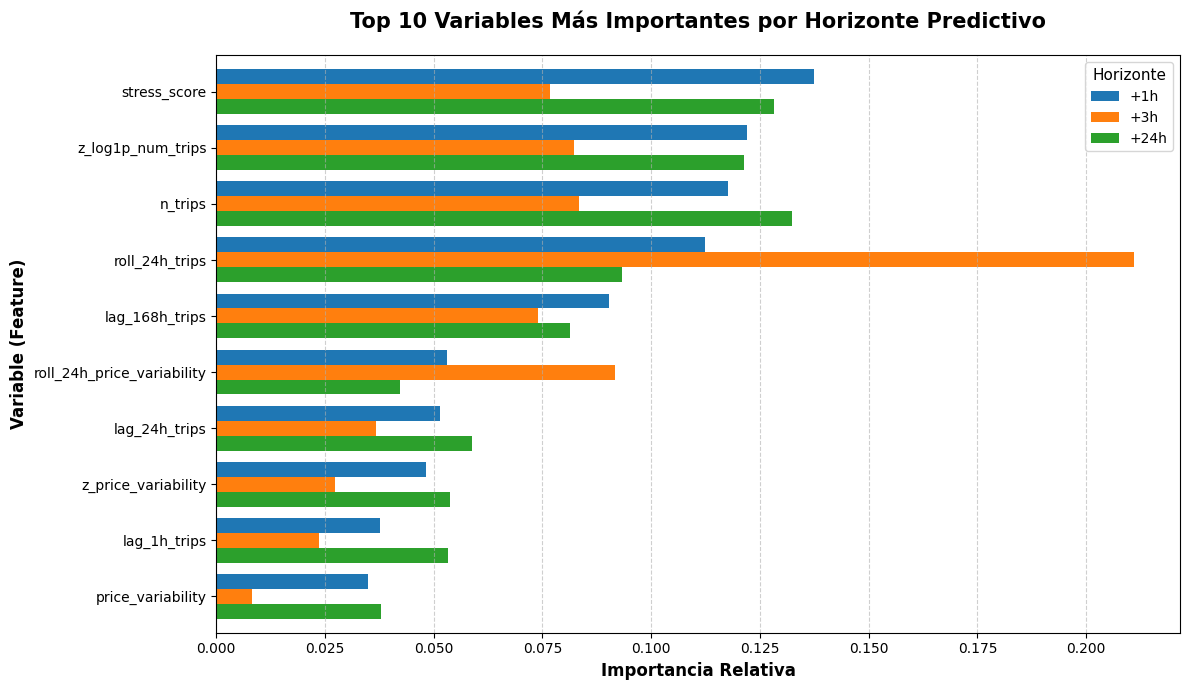

In [5]:
import matplotlib.pyplot as plt

plt.style.use("default")

df_all = pd.DataFrame()

# Cargar y cruzar importancias por target
for target in targets:
    csv_path = os.path.join(base_path, target, "random_forest_stress_spark_feature_importance.csv")

    df = pd.read_csv(csv_path)
    col_name = f"+{target.replace('t', '')}h"
    df = df[["feature", "importance"]].rename(columns={"importance": col_name})
    if df_all.empty:
        df_all = df
    else:
        df_all = pd.merge(df_all, df, on="feature", how="outer")

# Procesar y dibujar
df_all = df_all.fillna(0)
df_top = df_all.sort_values(by="+1h", ascending=False).head(10)
df_plot = df_top.set_index("feature")

fig, ax = plt.subplots(figsize=(12, 7))

colores = ["#1f77b4", "#ff7f0e", "#2ca02c"]
df_plot.plot(kind="barh", width=0.8, ax=ax, color=colores)

ax.invert_yaxis()
ax.set_title("Top 10 Variables Más Importantes por Horizonte Predictivo", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("Importancia Relativa", fontsize=12, fontweight="bold")
ax.set_ylabel("Variable (Feature)", fontsize=12, fontweight="bold")
ax.legend(title="Horizonte", title_fontsize="11", fontsize="10")
ax.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


**2. Heatmap de métricas**


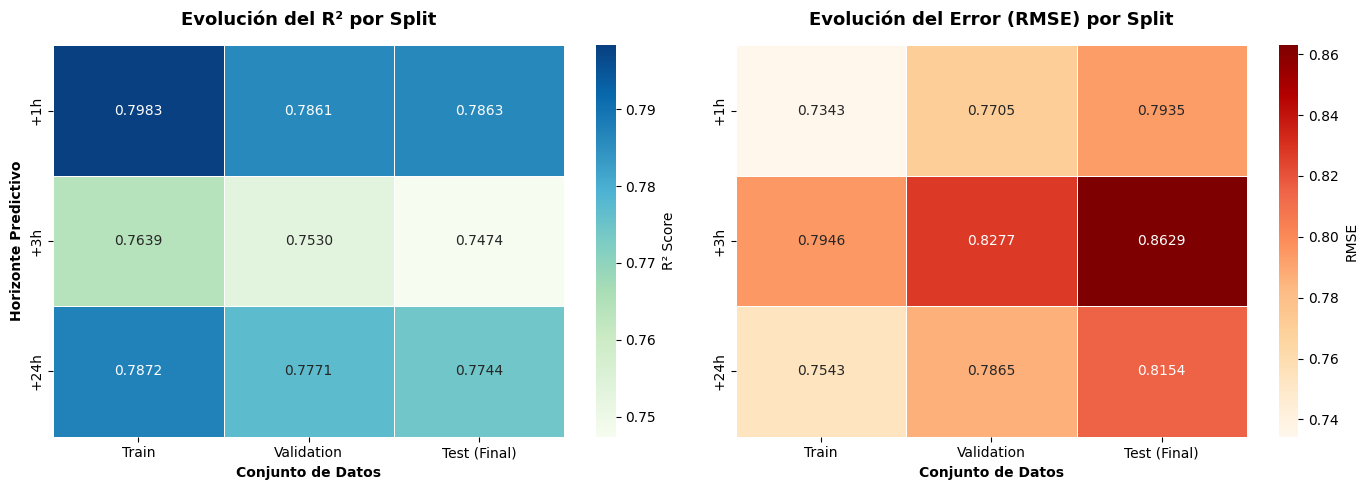

In [6]:
import seaborn as sns

# Separar las métricas en dos DataFrames distintos para los heatmaps
df_r2 = df_metrics.set_index('Target')[['Train R²', 'Val R²', 'Test Final R²']]
df_rmse = df_metrics.set_index('Target')[['Train RMSE', 'Val RMSE', 'Test Final RMSE']]

# Renombrar columnas para que quede más limpio en el gráfico
df_r2.columns = ['Train', 'Validation', 'Test (Final)']
df_rmse.columns = ['Train', 'Validation', 'Test (Final)']

# Crear la figura con dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap R² (Tonos azules/verdes: más oscuro es mejor)
sns.heatmap(df_r2, annot=True, fmt=".4f", cmap="GnBu", ax=axes[0], 
            cbar_kws={'label': 'R² Score'}, linewidths=.5)
axes[0].set_title('Evolución del R² por Split', pad=15, fontweight='bold', fontsize=13)
axes[0].set_ylabel('Horizonte Predictivo', fontweight='bold')
axes[0].set_xlabel('Conjunto de Datos', fontweight='bold')

# Heatmap RMSE (Tonos rojos/naranjas: más oscuro es peor/más error)
sns.heatmap(df_rmse, annot=True, fmt=".4f", cmap="OrRd", ax=axes[1], 
            cbar_kws={'label': 'RMSE'}, linewidths=.5)
axes[1].set_title('Evolución del Error (RMSE) por Split', pad=15, fontweight='bold', fontsize=13)
axes[1].set_ylabel('') # Ocultamos el eje Y porque es el mismo que el de la izquierda
axes[1].set_xlabel('Conjunto de Datos', fontweight='bold')


plt.tight_layout()
plt.show()


**3. Scatter plot: predicciones vs. valores reales**

El modelo reproduce adecuadamente la tendencia general entre valores reales y predichos, con una concentración de densidad alineada con la diagonal ideal. No obstante, se observa una dispersión considerable, lo que indica errores no despreciables incluso en regiones densas.

Se aprecia un sesgo sistemático leve hacia la media: los valores altos de estrés tienden a subestimarse, mientras que los valores bajos se sobreestiman. Además, el modelo parece presentar una cierta saturación en los valores predichos, dificultando la captura de picos extremos.

El rendimiento es más robusto en el rango de valores bajo-medio, donde se concentra la mayoría de las observaciones.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/29 10:35:23 WARN Utils: Your hostname, rosita, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/29 10:35:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 10:35:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/29 10:35:39 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711
26/04/29 10:35:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxT

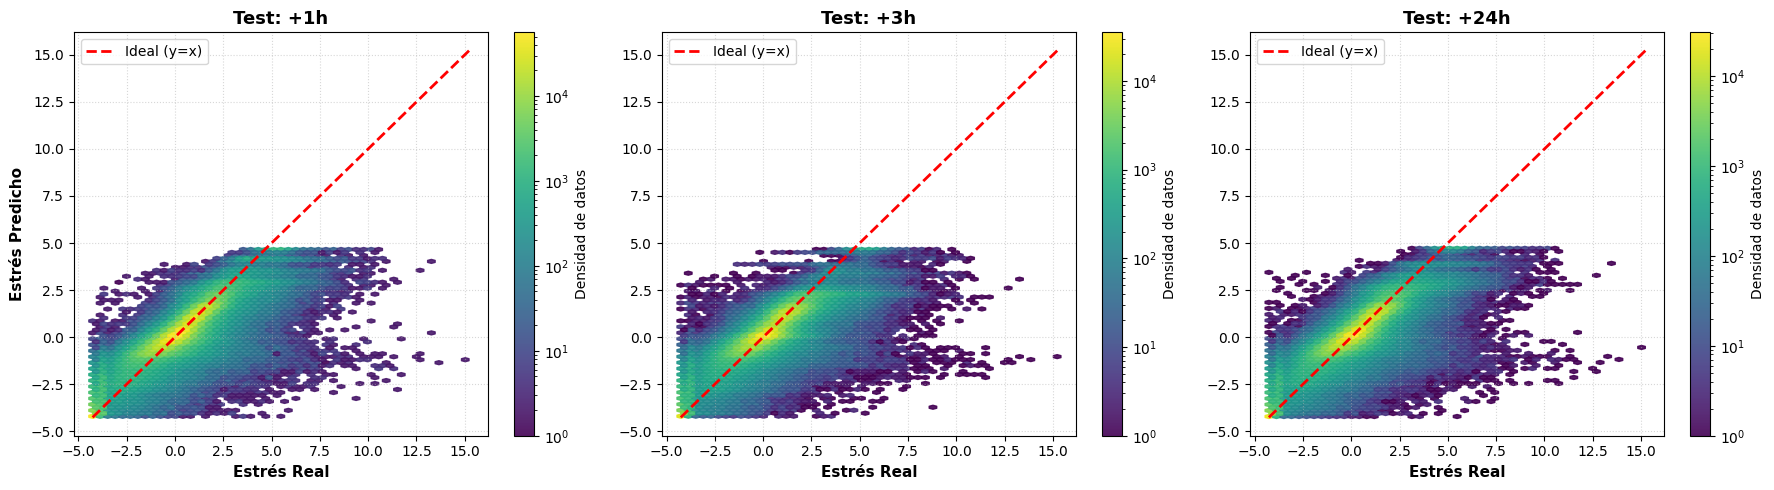

In [7]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel

# Iniciar SparkSession
spark = SparkSession.builder     .appName("Analisis_Test_RF")     .config("spark.driver.memory", "4g")     .getOrCreate()

# Cargar dataset completo
data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

# Configuración de figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]

base_model_path = "../outputs/ejercicio2/random_forest/"

for i, target in enumerate(targets):
    report_path = os.path.join(base_model_path, target, "random_forest_stress_spark_report.json")

    with open(report_path, "r") as f:
        data = json.load(f)
        bounds = data["split_params"]["bounds"]

    test_start_date = bounds["test_start"]
    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())

    model_path = os.path.join(base_model_path, target, "random_forest_stress_spark_model")

    try:
        modelo = PipelineModel.load(model_path)
        predicciones = modelo.transform(df_test)

        df_plot = predicciones.select(target_col, "prediction").toPandas()

        y_real = df_plot[target_col]
        y_pred = df_plot["prediction"]

        hb = axes[i].hexbin(y_real, y_pred, gridsize=50, cmap="viridis", mincnt=1, bins="log", alpha=0.9)

        min_val = min(y_real.min(), y_pred.min())
        max_val = max(y_real.max(), y_pred.max())
        axes[i].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Ideal (y=x)")

        axes[i].set_title(f"Test: {horizontes[i]}", fontsize=13, fontweight="bold")
        axes[i].set_xlabel("Estrés Real", fontsize=11, fontweight="bold")
        if i == 0:
            axes[i].set_ylabel("Estrés Predicho", fontsize=11, fontweight="bold")

        axes[i].legend(loc="upper left")
        axes[i].grid(True, linestyle=":", alpha=0.5)

        cb = fig.colorbar(hb, ax=axes[i])
        cb.set_label("Densidad de datos")

    except Exception as e:
        print(f"Error procesando target {target}: {e}")

plt.tight_layout()
plt.show()

spark.stop()


**4. Distribución de residuos** 

La distribución de residuos en los tres horizontes temporales muestra un comportamiento globalmente adecuado, con una clara concentración en torno a cero, lo que indica ausencia de sesgo global significativo.

La forma leptocúrtica de las distribuciones revela que la mayoría de las predicciones presentan errores pequeños, especialmente en los rangos más frecuentes del fenómeno. Sin embargo, la presencia de colas relativamente largas indica que existen errores no despreciables en ciertos casos, particularmente en situaciones menos habituales.

Se observa una ligera asimetría hacia residuos positivos, lo que sugiere una tendencia del modelo a subestimar valores altos de estrés, en línea con el comportamiento conservador observado previamente.

Asimismo, se aprecia una leve degradación del rendimiento a medida que aumenta el horizonte temporal, reflejada en una mayor dispersión de los residuos. Este comportamiento es consistente con el incremento de incertidumbre inherente a predicciones a más largo plazo.

Finalmente, los resultados sugieren una posible heterocedasticidad, donde la varianza del error aumenta en escenarios más extremos.


26/04/29 10:37:51 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


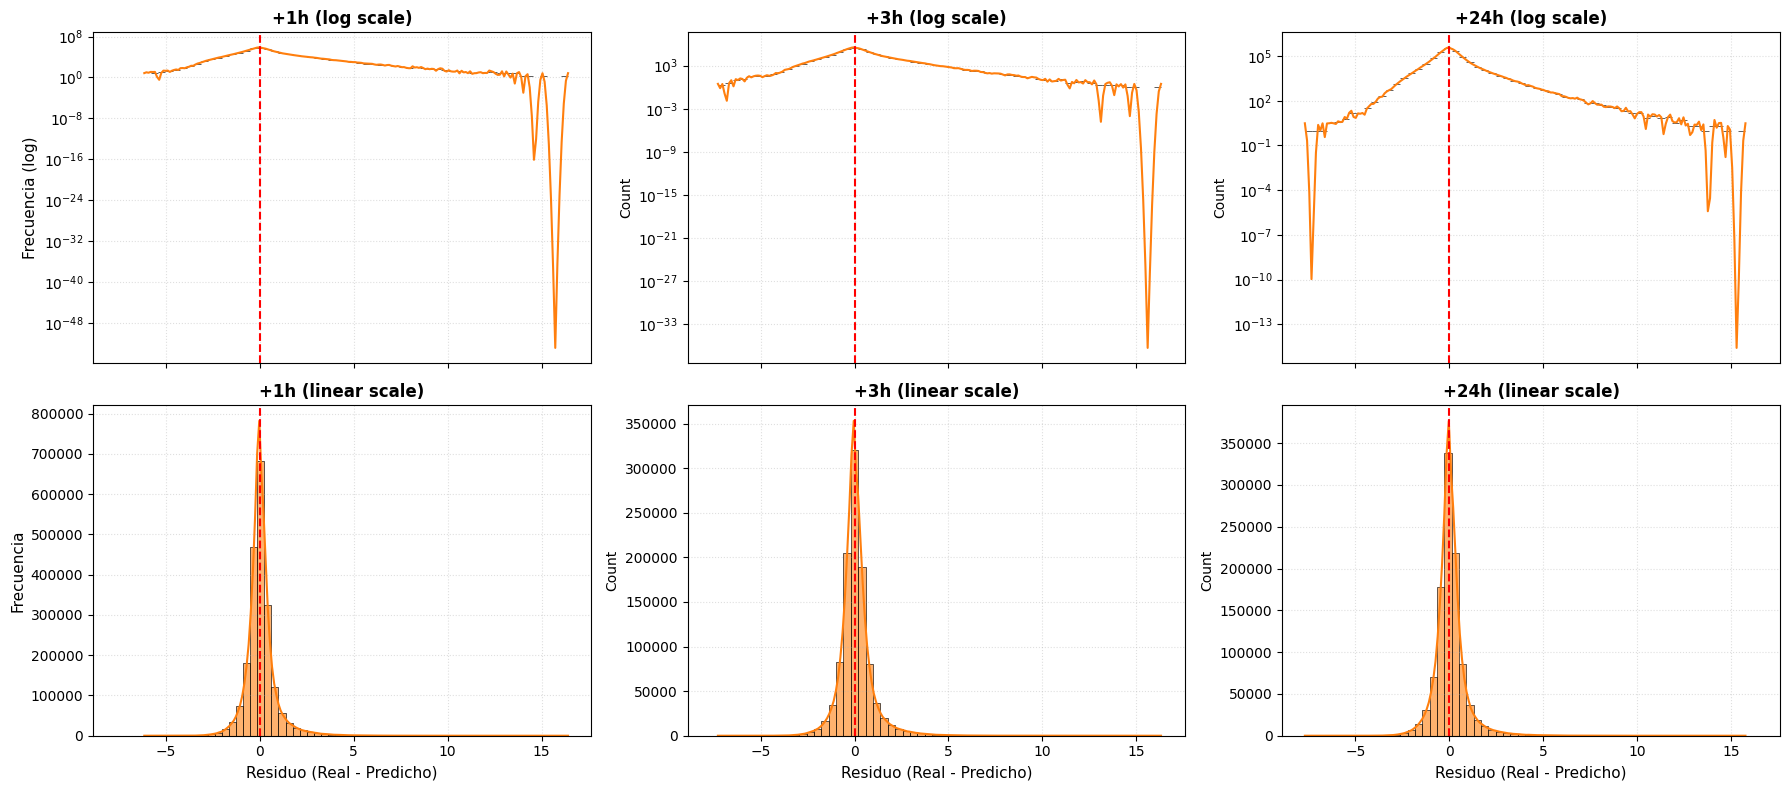

In [8]:
spark = SparkSession.builder.appName("Analisis_Test_RF").getOrCreate()

data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]
base_model_path = "../outputs/ejercicio2/random_forest/"

for i, target in enumerate(targets):
    report_path = os.path.join(base_model_path, target, "random_forest_stress_spark_report.json")
    with open(report_path, "r") as f:
        data = json.load(f)
    test_start_date = data["split_params"]["bounds"]["test_start"]

    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())

    model_path = os.path.join(base_model_path, target, "random_forest_stress_spark_model")

    try:
        modelo = PipelineModel.load(model_path)
        predicciones = modelo.transform(df_test)

        df_plot = predicciones.select(target_col, "prediction").toPandas()
        df_plot["residual"] = df_plot[target_col] - df_plot["prediction"]

        # Fila 0: escala log en eje Y
        ax_log = axes[0, i]
        sns.histplot(
            df_plot["residual"],
            bins=60,
            kde=True,
            ax=ax_log,
            color="#ff7f0e",
            edgecolor="black",
            alpha=0.6,
            log_scale=(False, True),
        )
        ax_log.axvline(0, color="red", linestyle="--", linewidth=1.5)
        ax_log.set_title(f"{horizontes[i]} (log scale)", fontsize=12, fontweight="bold")
        ax_log.grid(True, linestyle=":", alpha=0.4)

        # Fila 1: escala lineal
        ax_lin = axes[1, i]
        sns.histplot(
            df_plot["residual"],
            bins=60,
            kde=True,
            ax=ax_lin,
            color="#ff7f0e",
            edgecolor="black",
            alpha=0.6,
        )
        ax_lin.axvline(0, color="red", linestyle="--", linewidth=1.5)
        ax_lin.set_title(f"{horizontes[i]} (linear scale)", fontsize=12, fontweight="bold")
        ax_lin.grid(True, linestyle=":", alpha=0.4)

        if i == 0:
            ax_log.set_ylabel("Frecuencia (log)", fontsize=11)
            ax_lin.set_ylabel("Frecuencia", fontsize=11)

        ax_lin.set_xlabel("Residuo (Real - Predicho)", fontsize=11)

    except Exception as e:
        print(f"Error procesando target {target}: {e}")

plt.tight_layout()
plt.show()

spark.stop()


**5. Residuos vs. tiempo**

El modelo demuestra una robustez estructural notable al mantener la media de los residuos cercana a cero durante todo el periodo de test. Esta estabilidad confirma la ausencia de data drift, garantizando que las predicciones mantienen su validez técnica sin sufrir una degradación inmediata tras el entrenamiento inicial.

Se han detectado oscilaciones cíclicas en la tendencia de los errores, lo que revela que el modelo no captura con total exactitud la estacionalidad horaria de la ciudad. Estas fluctuaciones sugieren que el sistema tiende a ser ligeramente optimista o pesimista en franjas específicas, marcando una oportunidad de mejora futura.

La precisión es inversamente proporcional al horizonte temporal, mostrando un control casi total en las predicciones a corto plazo frente a una mayor volatilidad en las de largo plazo. El ensanchamiento de las ondas de error en horizontes lejanos es una consecuencia natural y esperada de la incertidumbre acumulada.

En conclusión, el sistema es plenamente apto para su despliegue operativo al presentar fallos predecibles y una varianza constante en el tiempo. La fiabilidad general es alta, siempre que se considere el aumento del margen de error en las planificaciones que superan el ciclo diario de veinticuatro horas.


26/04/29 10:40:24 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


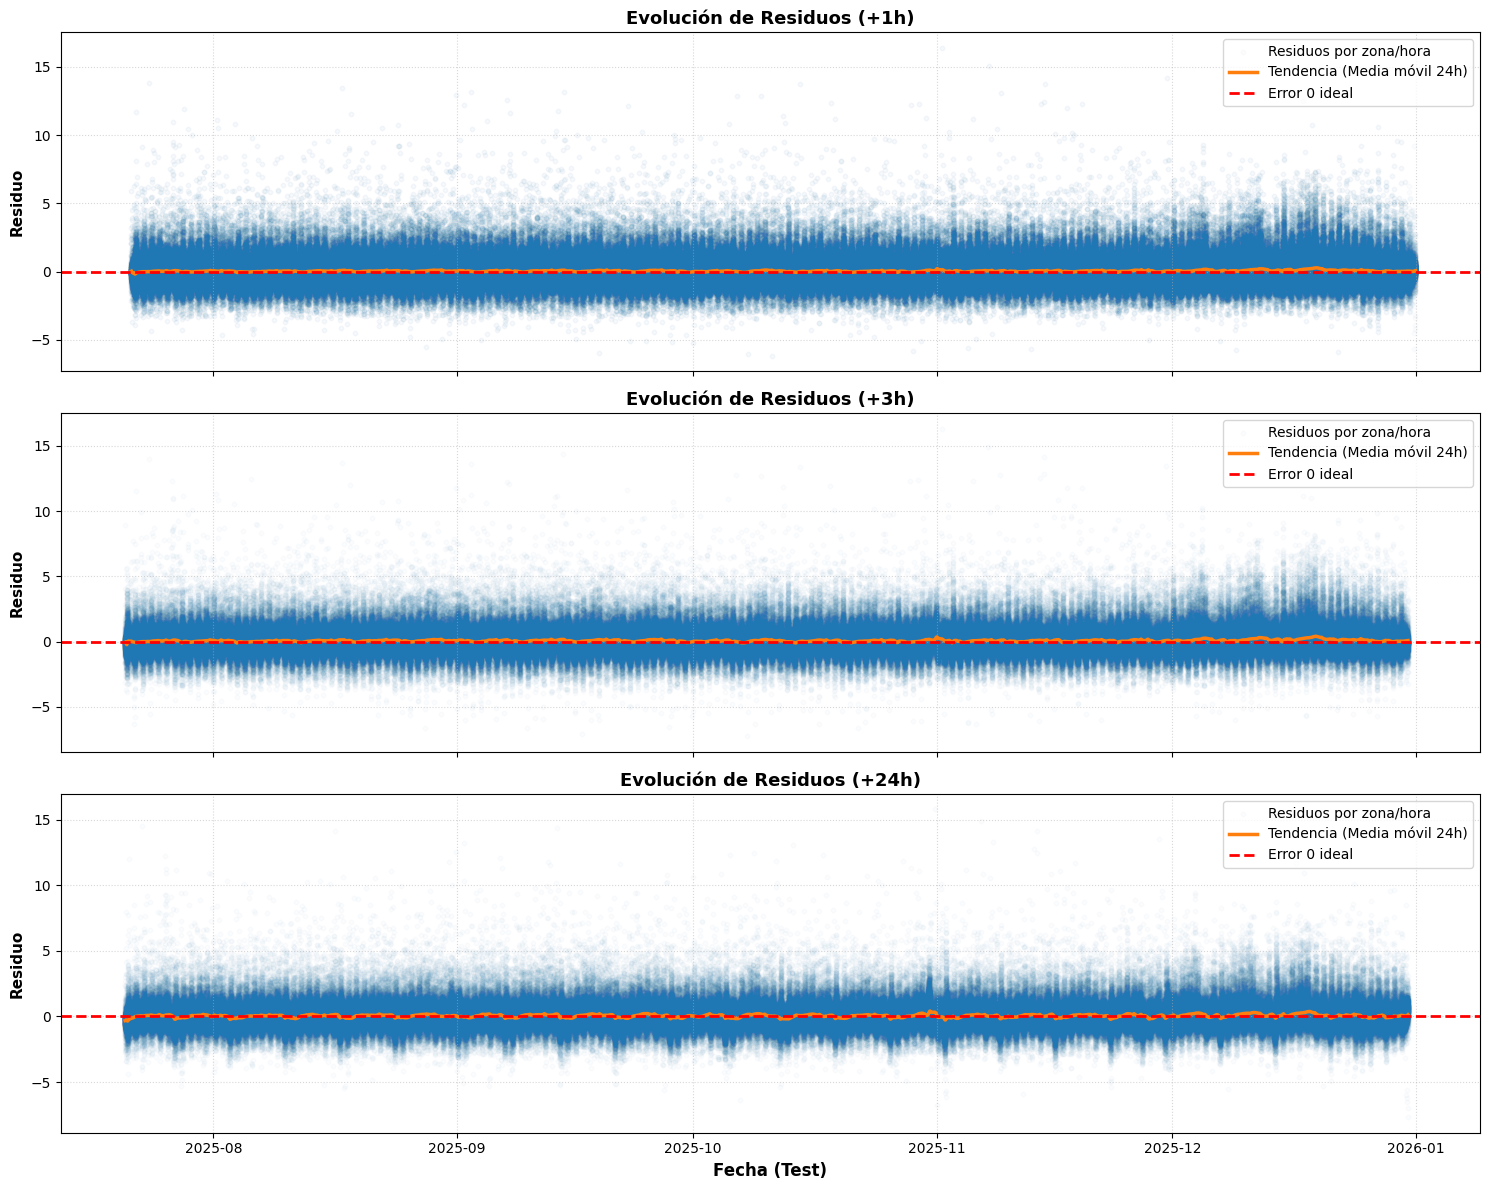

In [9]:
spark = SparkSession.builder.appName("Analisis_Test_RF").getOrCreate()

data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]
base_model_path = "../outputs/ejercicio2/random_forest/"

for i, target in enumerate(targets):
    report_path = os.path.join(base_model_path, target, "random_forest_stress_spark_report.json")
    with open(report_path, "r") as f:
        data = json.load(f)
    test_start_date = data["split_params"]["bounds"]["test_start"]

    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())

    model_path = os.path.join(base_model_path, target, "random_forest_stress_spark_model")

    try:
        modelo = PipelineModel.load(model_path)
        predicciones = modelo.transform(df_test)

        df_plot = predicciones.select("timestamp_hour", target_col, "prediction").toPandas()

        df_plot["timestamp_hour"] = pd.to_datetime(df_plot["timestamp_hour"])
        df_plot = df_plot.sort_values("timestamp_hour")
        df_plot["residual"] = df_plot[target_col] - df_plot["prediction"]

        axes[i].scatter(
            df_plot["timestamp_hour"],
            df_plot["residual"],
            alpha=0.02,
            color="#1f77b4",
            s=10,
            label="Residuos por zona/hora",
        )

        df_mean = df_plot.groupby("timestamp_hour")["residual"].mean().reset_index()
        df_mean["rolling_res"] = df_mean["residual"].rolling(window=24, min_periods=1).mean()

        axes[i].plot(
            df_mean["timestamp_hour"],
            df_mean["rolling_res"],
            color="#ff7f0e",
            linewidth=2.5,
            label="Tendencia (Media móvil 24h)",
        )

        axes[i].axhline(0, color="red", linestyle="--", linewidth=2, label="Error 0 ideal")

        axes[i].set_title(f"Evolución de Residuos ({horizontes[i]})", fontsize=13, fontweight="bold")
        axes[i].set_ylabel("Residuo", fontsize=11, fontweight="bold")
        axes[i].legend(loc="upper right")
        axes[i].grid(True, linestyle=":", alpha=0.5)

    except Exception as e:
        print(f"Error procesando target {target}: {e}")

axes[2].set_xlabel("Fecha (Test)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

spark.stop()


**6. Curva de tuning**

La curva de optimización permite visualizar la exploración de hiperparámetros y el mejor trial (mínimo RMSE de validación) en cada horizonte. En Random Forest, se aprecia una zona de rendimiento estable alrededor de profundidades altas moderadas (`maxDepth=8`) y bosques de tamaño medio (`80-100` árboles).


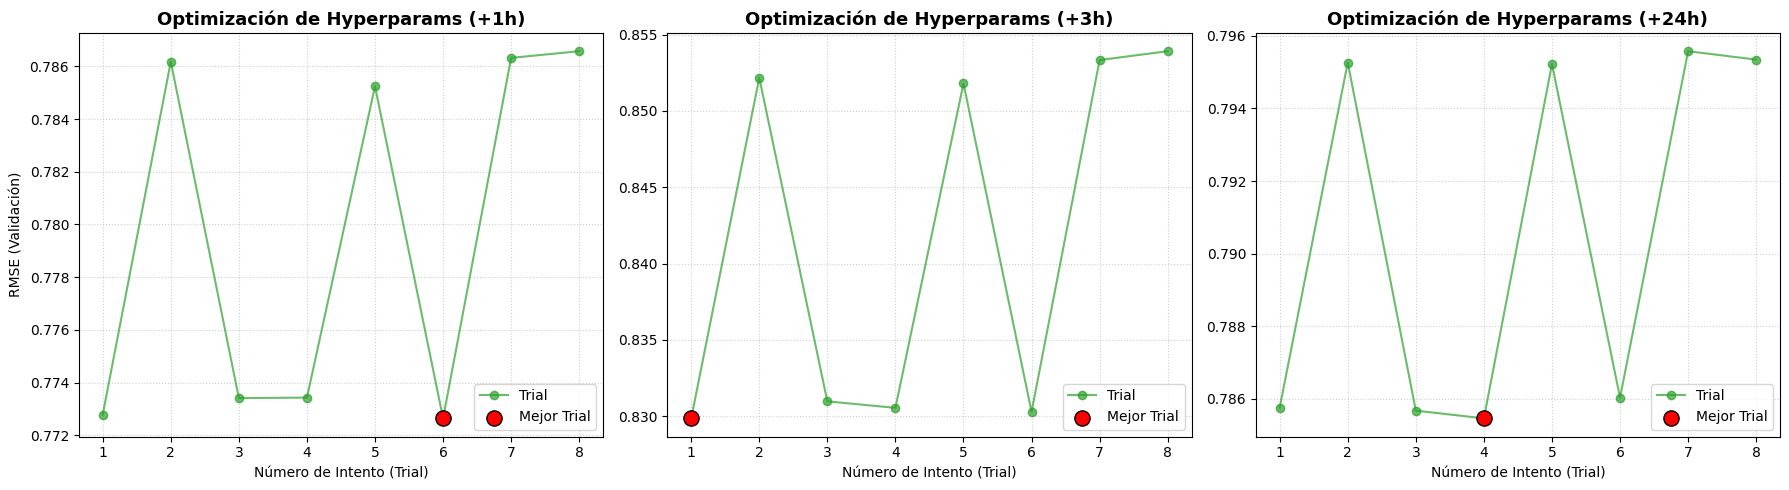

In [11]:
base_model_path = "../outputs/ejercicio2/random_forest/"
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]

fig6, axes6 = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    trials_path = os.path.join(base_model_path, target, "random_forest_stress_spark_tuning_trials.csv")

    if os.path.exists(trials_path):
        df_trials = pd.read_csv(trials_path)
        df_trials = df_trials[df_trials["status"] == "ok"].copy()

        axes6[i].plot(
            df_trials["trial"],
            df_trials["val_rmse"],
            marker="o",
            linestyle="-",
            color="#2ca02c",
            alpha=0.7,
            label="Trial",
        )

        best_idx = df_trials["val_rmse"].idxmin()
        best_trial = df_trials.loc[best_idx]

        axes6[i].scatter(
            best_trial["trial"],
            best_trial["val_rmse"],
            color="red",
            s=120,
            zorder=5,
            label="Mejor Trial",
            edgecolors="black",
        )

        axes6[i].set_title(f"Optimización de Hyperparams ({horizontes[i]})", fontsize=13, fontweight="bold")
        axes6[i].set_xlabel("Número de Intento (Trial)")
        if i == 0:
            axes6[i].set_ylabel("RMSE (Validación)")
        axes6[i].grid(True, linestyle=":", alpha=0.6)
        axes6[i].legend()
    else:
        axes6[i].text(0.5, 0.5, f"Archivo no encontrado: {target}", ha="center")

plt.tight_layout()
plt.show()


**7. Comparativa de RMSE por horizonte temporal**


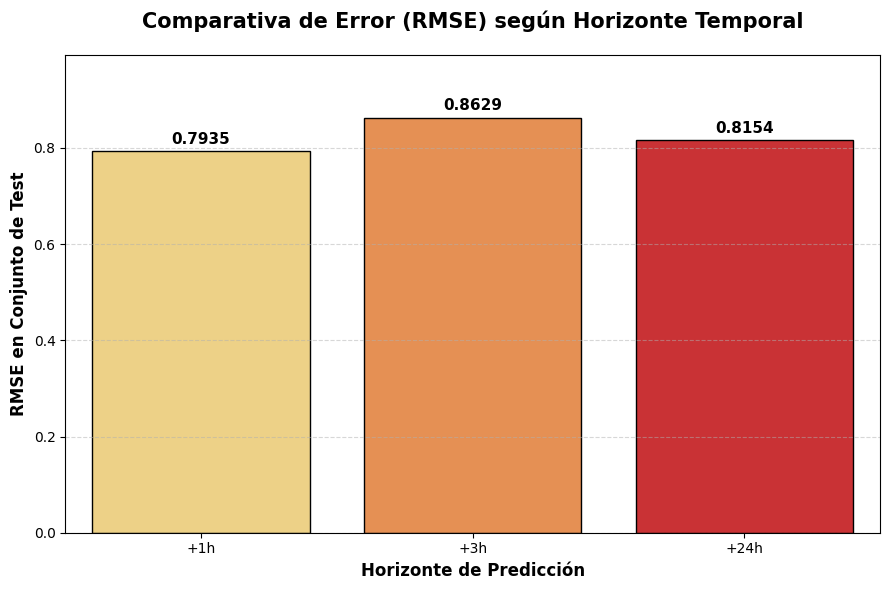

In [12]:
rmse_test_values = []

for target in targets:
    report_path = os.path.join(base_model_path, target, "random_forest_stress_spark_report.json")
    if os.path.exists(report_path):
        with open(report_path, "r") as f:
            report = json.load(f)
            val = report["metrics"]["train_val_refit"]["test_unseen"]["rmse"]
            rmse_test_values.append(val)
    else:
        rmse_test_values.append(0)

plt.figure(figsize=(9, 6))
colors = sns.color_palette("YlOrRd", len(horizontes))
sns.barplot(
    x=horizontes,
    y=rmse_test_values,
    hue=horizontes,
    palette=colors,
    edgecolor="black",
    legend=False,
)

plt.title("Comparativa de Error (RMSE) según Horizonte Temporal", fontsize=15, fontweight="bold", pad=20)
plt.ylabel("RMSE en Conjunto de Test", fontsize=12, fontweight="bold")
plt.xlabel("Horizonte de Predicción", fontsize=12, fontweight="bold")

for i, v in enumerate(rmse_test_values):
    plt.text(i, v + (max(rmse_test_values) * 0.01), f"{v:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.ylim(0, max(rmse_test_values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
